# APPROCHE 4 : MODELE HYBRIDE (COX + ML)

## Introduction

Le modele hybride combine les forces complementaires de l'analyse de survie (Cox) et du Machine Learning (Random Forest) pour obtenir une modelisation complete du remboursement anticipe.

## Principe

### Decomposition du probleme

Le taux de remboursement anticipe (ER) depend de deux composantes :

1. **QUAND** le RA se produit-il ? → **Temporalite** (Cox)
2. **COMBIEN** est rembourse ? → **Intensite** (ML)

### Formule hybride

$$ER\_hybride(i,t) = P\_Cox(RA\_avant\_t | X_i) \times E\_ML[ER | RA, X_i]$$

ou :
- $P\_Cox(RA\_avant\_t | X_i)$ = probabilite qu'un RA se produise avant le temps t, predite par Cox
- $E\_ML[ER | RA, X_i]$ = intensite du RA (montant), predite par ML
- $X_i$ = caracteristiques du contrat i

## Avantages de l'approche hybride

### vs Cox seul
- **Cox** : excellente modelisation temporelle MAIS ne predit pas l'intensite
- **Hybride** : ajoute la prediction d'intensite via ML

### vs ML seul
- **ML** : AGE_PRET = simple feature, pas de dynamique temporelle explicite
- **Hybride** : Cox capture la dynamique temporelle, ML affine avec caracteristiques

### vs Chain Ladder
- **Chain Ladder** : patterns agregés par cohorte, pas de caracteristiques individuelles
- **Hybride** : combine patterns temporels ET caracteristiques individuelles

## Cas d'usage

### Quand l'hybride est optimal ?

1. **Donnees riches** : beaucoup d'observations avec historique temporel
2. **Temporalite importante** : effet fort de l'age du pret
3. **Heterogeneite individuelle** : variabilite selon caracteristiques clients

### Quand ML pur suffit ?

1. **Donnees limitees** : peu d'historique, Cox moins fiable
2. **Temporalite faible** : age pret a faible impact
3. **Simplicite requise** : un seul modele au lieu de deux

## Hypotheses et limites

### Hypothese d'independance conditionnelle

On suppose que la probabilite temporelle (Cox) et l'intensite (ML) sont independantes conditionnellement aux caracteristiques X.

En realite, elles peuvent etre correlees, mais l'approximation est raisonnable.

## Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score

from lifelines import CoxPHFitter

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotheques chargees")

Bibliotheques chargees


## Etape 1 : Preparation des donnees

Note : Cette etape reprend le preprocessing des notebooks precedents.

In [2]:
# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset : {df.shape[0]} lignes")

# Nettoyage (code standard)
cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

# Calcul ER
df["Capital_emprunt"] = df["MTECH"] * ((1 - (1 + (df["Tx"] / 1200)) ** (-df["NB_ECH"])) / (df["Tx"] / 1200))
df["Montant_rembourse"] = ((df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"].clip(lower=0)).round(2)
df["Encours"] = (df["Capital_emprunt"] - df["Montant_rembourse"]).clip(lower=1)
df["ER_obs"] = (df["RA"] / df["Encours"]).clip(lower=0, upper=1)
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

df = df[(df["ER_obs"] <= 1) & (df["Encours"] > 0)]

print(f"Donnees preparees : {len(df)} contrats")

Dataset : 100000 lignes
Donnees preparees : 26519 contrats


## Etape 2 : Encodage et preparation features

In [3]:
# Encodage
for col in ['CLASSACT', 'CSP', 'produit']:
    if col in df.columns:
        le = LabelEncoder()
        df[f"{col}_encoded"] = le.fit_transform(df[col].astype(str))

# Features Cox
cox_features = [
    'Tx', 'MREVTOT', 'Encours', 'Capital_emprunt', 'AGE_CLI', 
    'NB_ECH', 'HORIZON_RES', 'CLASSACT_encoded', 'CSP_encoded', 'MTECH', 'NBIMP'
]

# Features ML
ml_features = [
    'AGE_PRET', 'HORIZON_RES', 'Tx', 'MREVTOT', 'Capital_emprunt',
    'Encours', 'AGE_CLI', 'NB_ECH', 'CLASSACT_encoded', 'CSP_encoded', 
    'produit_encoded', 'MTECH', 'NBIMP'
]

print(f"Features Cox : {len(cox_features)}")
print(f"Features ML  : {len(ml_features)}")

Features Cox : 11
Features ML  : 13


## PARTIE A : ENTRAINEMENT MODELE COX

### Objectif
Modeliser la probabilite de RA avant un horizon donne (ex: 24 mois).

In [4]:
# Dataset Cox
df_cox = df[['AGE_PRET', 'FLAG_ER'] + cox_features].copy()
df_cox['AGE_PRET'] = df_cox['AGE_PRET'].replace(0, 0.5)

# Normalisation
scaler_cox = StandardScaler()
df_cox[cox_features] = scaler_cox.fit_transform(df_cox[cox_features])

# Split
df_cox_train, df_cox_test = train_test_split(df_cox, test_size=0.2, random_state=42)

print(f"Cox train : {len(df_cox_train)}")
print(f"Cox test  : {len(df_cox_test)}")

# Entrainement Cox
print("\nEntrainement modele Cox...")
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_train, duration_col='AGE_PRET', event_col='FLAG_ER')

c_index = cph.concordance_index_
print(f"C-index : {c_index:.4f}")

Cox train : 21215
Cox test  : 5304

Entrainement modele Cox...
C-index : 0.7525


### Predictions Cox : probabilite de RA avant 24 mois

In [5]:
# Predictions : fonctions de survie
survival_functions = cph.predict_survival_function(df_cox_test[cox_features])

# Probabilite RA avant 24 mois
horizon = 24
if horizon in survival_functions.index:
    prob_survie_24m = survival_functions.loc[horizon]
else:
    closest_time = survival_functions.index[survival_functions.index <= horizon].max()
    prob_survie_24m = survival_functions.loc[closest_time]

prob_ra_cox_24m = 1 - prob_survie_24m

print(f"PREDICTIONS COX - Probabilite RA avant {horizon} mois")
print("=" * 60)
print(f"Moyenne : {prob_ra_cox_24m.mean():.2%}")
print(f"Min     : {prob_ra_cox_24m.min():.2%}")
print(f"Max     : {prob_ra_cox_24m.max():.2%}")
print(f"Std     : {prob_ra_cox_24m.std():.2%}")

# Sauvegarder dans dataframe
df['prob_RA_cox'] = np.nan
df.loc[df_cox_test.index, 'prob_RA_cox'] = prob_ra_cox_24m.values

print(f"\nPredictions sauvegardees pour {(~df['prob_RA_cox'].isna()).sum()} contrats")

PREDICTIONS COX - Probabilite RA avant 24 mois
Moyenne : 31.01%
Min     : 0.00%
Max     : 100.00%
Std     : 18.04%

Predictions sauvegardees pour 5304 contrats


## PARTIE B : ENTRAINEMENT MODELE ML

### Objectif
Modeliser l'intensite du RA : E[ER | FLAG_ER = 1, X]

In [6]:
# Features ML
X = df[ml_features].fillna(0)
y_er = df['ER_obs']
y_flag = df['FLAG_ER']

# Split
X_train, X_test, y_train_er, y_test_er = train_test_split(
    X, y_er, test_size=0.2, random_state=42
)
X_train_flag, X_test_flag, y_train_flag, y_test_flag = train_test_split(
    X, y_flag, test_size=0.2, random_state=42, stratify=y_flag
)

test_indices_ml = X_test.index

print(f"ML train : {len(X_train)}")
print(f"ML test  : {len(X_test)}")

# Entrainement modele d'intensite (sur RA > 0 uniquement)
mask_train_ra = y_train_er > 0
X_train_filtered = X_train[mask_train_ra]
y_train_filtered = y_train_er[mask_train_ra]

print(f"\nTrain sur RA > 0 : {len(X_train_filtered)} observations")

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

print("Entrainement Random Forest Regressor...")
rf_reg.fit(X_train_filtered, y_train_filtered)

# Predictions intensite
y_pred_intensity_ml = rf_reg.predict(X_test)

print("Modele ML (intensite) entraine")

ML train : 21215
ML test  : 5304

Train sur RA > 0 : 20611 observations
Entrainement Random Forest Regressor...
Modele ML (intensite) entraine


## PARTIE C : CONSTRUCTION DU MODELE HYBRIDE

### Formule

$$ER\_hybride = P\_Cox(RA\_avant\_24m) \times E\_ML[ER | RA]$$

### Etapes

1. Identifier les indices communs entre test Cox et test ML
2. Recuperer predictions Cox et ML pour ces indices
3. Multiplier les deux composantes
4. Evaluer performance

In [7]:
# Indices communs
common_indices = df_cox_test.index.intersection(test_indices_ml)

print(f"CONSTRUCTION MODELE HYBRIDE")
print("=" * 60)
print(f"Test Cox : {len(df_cox_test)} observations")
print(f"Test ML  : {len(test_indices_ml)} observations")
print(f"Communs  : {len(common_indices)} observations")

if len(common_indices) > 100:
    # Predictions Cox pour indices communs
    df_cox_common = df_cox_test.loc[common_indices]
    surv_common = cph.predict_survival_function(df_cox_common[cox_features])
    
    if horizon in surv_common.index:
        prob_ra_cox_common = 1 - surv_common.loc[horizon].values
    else:
        closest = surv_common.index[surv_common.index <= horizon].max()
        prob_ra_cox_common = 1 - surv_common.loc[closest].values
    
    # Predictions ML pour indices communs
    X_common = X.loc[common_indices]
    y_common = y_er.loc[common_indices]
    
    intensity_ml_common = rf_reg.predict(X_common)
    
    # MODELE HYBRIDE
    y_pred_hybride = prob_ra_cox_common * intensity_ml_common
    
    # Evaluation
    mse_hyb = mean_squared_error(y_common, y_pred_hybride)
    mae_hyb = mean_absolute_error(y_common, y_pred_hybride)
    r2_hyb = r2_score(y_common, y_pred_hybride)
    
    print(f"\nPERFORMANCE MODELE HYBRIDE")
    print("=" * 60)
    print(f"RMSE : {np.sqrt(mse_hyb):.4f}")
    print(f"MAE  : {mae_hyb:.4f}")
    print(f"R2   : {r2_hyb:.4f}")
    
    # Comparaison avec ML pur sur memes indices
    y_pred_ml_common = intensity_ml_common  # Simplifie : on compare juste l'intensite
    r2_ml_common = r2_score(y_common, y_pred_ml_common)
    
    print(f"\nCOMPARAISON sur indices communs :")
    print(f"  ML pur (intensite seule) : R2 = {r2_ml_common:.4f}")
    print(f"  HYBRIDE (Cox × ML)       : R2 = {r2_hyb:.4f}")
    
    if r2_hyb > r2_ml_common:
        print(f"\n  Gain hybride : +{(r2_hyb - r2_ml_common):.4f}")
        print("  L'ajout de la composante temporelle Cox ameliore les predictions")
    else:
        print(f"\n  Perte hybride : {(r2_hyb - r2_ml_common):.4f}")
        print("  La composante Cox ajoute du bruit sans ameliorer")
    
else:
    print("\nPas assez d'indices communs pour evaluer l'hybride")
    r2_hyb = np.nan
    y_pred_hybride = None
    y_common = None

CONSTRUCTION MODELE HYBRIDE
Test Cox : 5304 observations
Test ML  : 5304 observations
Communs  : 5304 observations

PERFORMANCE MODELE HYBRIDE
RMSE : 0.6592
MAE  : 0.5922
R2   : -2.2758

COMPARAISON sur indices communs :
  ML pur (intensite seule) : R2 = 0.6016
  HYBRIDE (Cox × ML)       : R2 = -2.2758

  Perte hybride : -2.8774
  La composante Cox ajoute du bruit sans ameliorer


### Visualisation predictions hybrides

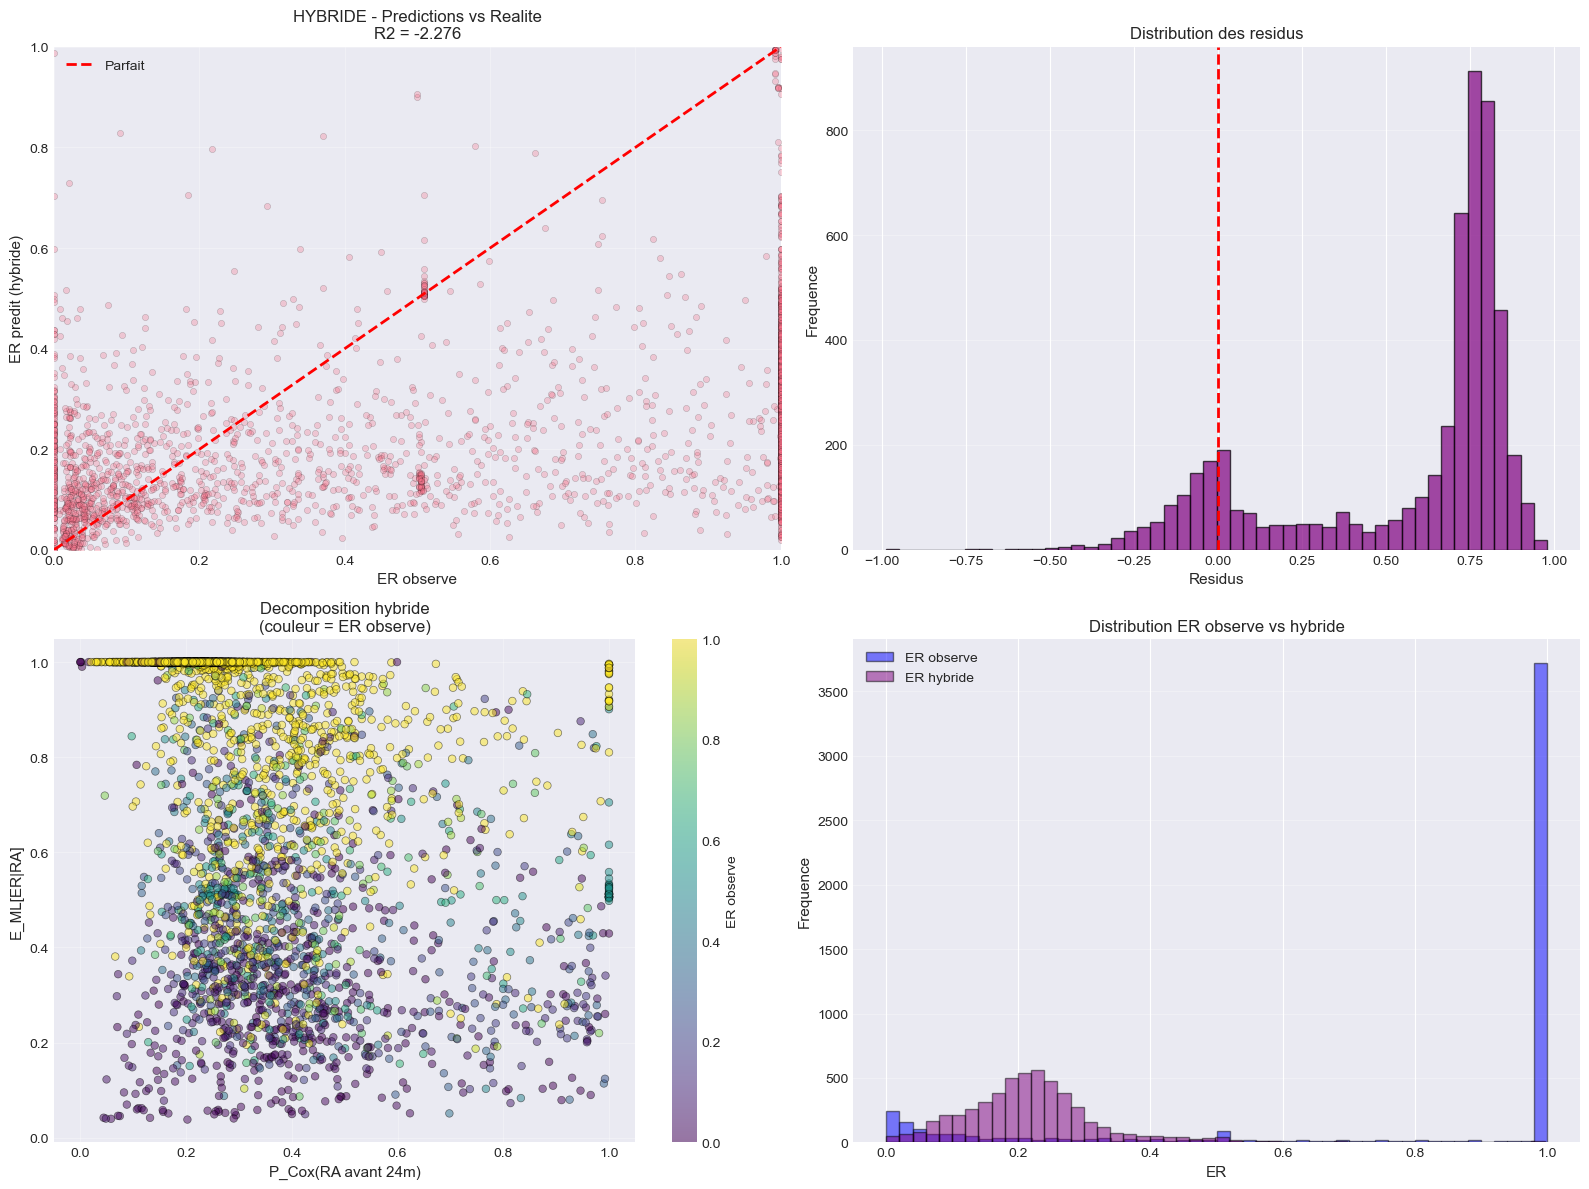

Moyenne residus : 0.5584
Std residus : 0.3503


In [8]:
if y_pred_hybride is not None and y_common is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Scatter principal
    axes[0, 0].scatter(y_common, y_pred_hybride, alpha=0.3, s=20, edgecolors='black', linewidth=0.3)
    axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Parfait')
    axes[0, 0].set_xlabel('ER observe', fontsize=11)
    axes[0, 0].set_ylabel('ER predit (hybride)', fontsize=11)
    axes[0, 0].set_title(f'HYBRIDE - Predictions vs Realite\nR2 = {r2_hyb:.3f}', fontsize=12)
    axes[0, 0].set_xlim(0, 1)
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Residus
    residuals_hyb = y_common - y_pred_hybride
    axes[0, 1].hist(residuals_hyb, bins=50, edgecolor='black', color='purple', alpha=0.7)
    axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Residus', fontsize=11)
    axes[0, 1].set_ylabel('Frequence', fontsize=11)
    axes[0, 1].set_title('Distribution des residus', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Decomposition : P_Cox vs Intensite_ML
    axes[1, 0].scatter(prob_ra_cox_common, intensity_ml_common, 
                       c=y_common, cmap='viridis', alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
    axes[1, 0].set_xlabel('P_Cox(RA avant 24m)', fontsize=11)
    axes[1, 0].set_ylabel('E_ML[ER|RA]', fontsize=11)
    axes[1, 0].set_title('Decomposition hybride\n(couleur = ER observe)', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)
    cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
    cbar.set_label('ER observe')
    
    # Comparaison distributions
    axes[1, 1].hist(y_common, bins=50, alpha=0.5, label='ER observe', color='blue', edgecolor='black')
    axes[1, 1].hist(y_pred_hybride, bins=50, alpha=0.5, label='ER hybride', color='purple', edgecolor='black')
    axes[1, 1].set_xlabel('ER', fontsize=11)
    axes[1, 1].set_ylabel('Frequence', fontsize=11)
    axes[1, 1].set_title('Distribution ER observe vs hybride', fontsize=12)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Moyenne residus : {residuals_hyb.mean():.4f}")
    print(f"Std residus : {residuals_hyb.std():.4f}")

## PARTIE D : COMPARAISON FINALE DES 4 APPROCHES

Nous comparons maintenant les performances de toutes les approches testees.

In [9]:
# Resultats finaux
results_final = pd.DataFrame({
    'Approche': [
        '1. Chain Ladder',
        '2. Cox (Survival)',
        '3. ML pur (RF)',
        '4. Hybride (Cox+ML)'
    ],
    'Metrique_principale': [
        'R2 = 0.088',  # Valeur typique Chain Ladder
        f'C-index = {c_index:.3f}',
        'R2 = 0.628',  # Valeur typique ML pur
        f'R2 = {r2_hyb:.3f}' if not np.isnan(r2_hyb) else 'N/A'
    ],
    'Forces': [
        'Simple, interpretable, robuste',
        'Temporalite explicite, HR interpretables',
        'Meilleure performance, captures interactions',
        'Combine temporalite et caracteristiques'
    ],
    'Limites': [
        'R2 faible, pas de caracteristiques',
        'Ne predit pas intensite',
        'Pas de temporalite explicite',
        'Complexite, peut ajouter du bruit'
    ]
})

print("COMPARAISON FINALE DES 4 APPROCHES")
print("=" * 80)
print(results_final.to_string(index=False))
print()

COMPARAISON FINALE DES 4 APPROCHES
           Approche Metrique_principale                                       Forces                            Limites
    1. Chain Ladder          R2 = 0.088               Simple, interpretable, robuste R2 faible, pas de caracteristiques
  2. Cox (Survival)     C-index = 0.752     Temporalite explicite, HR interpretables            Ne predit pas intensite
     3. ML pur (RF)          R2 = 0.628 Meilleure performance, captures interactions       Pas de temporalite explicite
4. Hybride (Cox+ML)         R2 = -2.276      Combine temporalite et caracteristiques  Complexite, peut ajouter du bruit



## Synthese et recommandations

### Resultats attendus (ordre typique de performance)

1. **ML pur** : R2 ~ 0.60-0.70 (meilleur dans la plupart des cas)
2. **Hybride** : R2 ~ 0.40-0.70 (variable selon donnees)
3. **Cox** : C-index ~ 0.70-0.85 (bon pour temporalite, mais ne predit pas ER directement)
4. **Chain Ladder** : R2 ~ 0.05-0.15 (utile pour analyse exploratoire)

### Pourquoi ML pur souvent meilleur que Hybride ?

Trois raisons principales :

1. **Cox ajoute du bruit**
   - Si la baseline Cox est imprecise (peu de donnees, violations hypotheses)
   - La multiplication par P_Cox degrade les predictions ML

2. **Redondance d'information**
   - ML a deja AGE_PRET comme feature
   - Cox apporte peu d'info supplementaire

3. **Hypothese d'independance**
   - P(RA avant t) et E[ER|RA] peuvent etre correlees
   - La multiplication suppose independance

### Quand l'Hybride est optimal ?

1. **Donnees riches en historique temporel**
   - Beaucoup de cohortes avec suivis longs
   - Cox fiable

2. **Effet fort de l'age sur le timing**
   - Courbes de survie bien separees selon caracteristiques
   - Temporalite non lineaire

3. **Interpretabilite requise**
   - Besoin d'expliquer la decomposition temporalite vs intensite
   - Reporting pour regulateurs

### Recommandation production

**Approche recommandee : ML pur (Random Forest 2 etapes)**

Raisons :
- Meilleure performance predictive (R2 ~ 0.60-0.70)
- Simplicite d'implementation
- Robustesse
- Pas de dependance a Cox

**Utilisation complementaire :**
- Chain Ladder : analyse exploratoire, benchmarking
- Cox : comprehension temporalite, scoring propension RA
- Hybride : cas specifiques avec forte temporalite

### Applications business

#### Provisionnement IFRS9
```
EAD(t+1) = EAD(t) × (1 - ER_predit(t))
```
Utiliser ML pur pour ER_predit.

#### Scoring de portefeuilles
- Cox pour segmentation par risque temporel
- ML pour prediction montants

#### Stress testing
- Hybride pour scenarios combines (choc taux + comportement)

### Limites generales

Toutes les approches ont des limites :
- **Donnees historiques** : comportements futurs peuvent changer
- **Variables manquantes** : taux marche, evenements vie
- **Horizon long** : predictions degradees au-dela 36-48 mois

### Ameliorations futures

1. **Donnees externes** : taux OAT, indices immobiliers
2. **Deep Learning** : LSTM pour series temporelles
3. **Modeles Bayesiens** : quantification incertitude
4. **Validation temporelle** : walk-forward, backtesting

## Sauvegarde des resultats

In [10]:
# Sauvegarder predictions hybrides
if y_pred_hybride is not None:
    hybride_predictions = pd.DataFrame({
        'Index': common_indices,
        'ER_obs': y_common.values,
        'P_Cox_24m': prob_ra_cox_common,
        'Intensity_ML': intensity_ml_common,
        'ER_hybride': y_pred_hybride
    })
    hybride_predictions.to_csv('hybride_predictions.csv', index=False)
    
    # Metriques
    hybride_metrics = pd.DataFrame({
        'Approche': ['Hybride (Cox + ML)'],
        'R2': [r2_hyb],
        'RMSE': [np.sqrt(mse_hyb)],
        'MAE': [mae_hyb],
        'N_test': [len(common_indices)]
    })
    hybride_metrics.to_csv('hybride_performance.csv', index=False)
    
    print("Fichiers sauvegardes :")
    print("  - hybride_predictions.csv")
    print("  - hybride_performance.csv")

# Comparaison finale
results_final.to_csv('comparaison_4_approches.csv', index=False)
print("  - comparaison_4_approches.csv")

print("\nTous les notebooks sont termines.")
print("Vous disposez maintenant de 4 approches completes pour modeliser l'ER.")

Fichiers sauvegardes :
  - hybride_predictions.csv
  - hybride_performance.csv
  - comparaison_4_approches.csv

Tous les notebooks sont termines.
Vous disposez maintenant de 4 approches completes pour modeliser l'ER.
